<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/house_regression_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.neighbors import KNeighborsRegressor
import pickle



df = pd.read_csv("Housing.csv")

# analyze and cleaning step

In [ ]:
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
# print(df.isnull().sum())
# print(df.isnull().sum().sum())

First 5 Rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Shape:
(545, 13)

Column Names:
Index(['price', 'area', 'bedrooms', 'bathroo

In [ ]:
print(df.select_dtypes(include='object').columns)
print(df['furnishingstatus'].value_counts())

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [ ]:
# corr = df_encode_obj.corr()

# print(corr['price'].sort_values(ascending=False))

In [ ]:
df_encode_obj = pd.get_dummies(df, columns=['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus']).astype(int)

In [ ]:
df_encode_obj.head(5)

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,0,1,1,0,...,0,1,0,0,1,0,1,1,0,0
1,12250000,8960,4,4,4,3,0,1,1,0,...,0,1,0,0,1,1,0,1,0,0
2,12250000,9960,3,2,2,2,0,1,1,0,...,1,1,0,1,0,0,1,0,1,0
3,12215000,7500,4,2,2,3,0,1,1,0,...,1,1,0,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,0,1,0,1,...,1,1,0,0,1,1,0,1,0,0


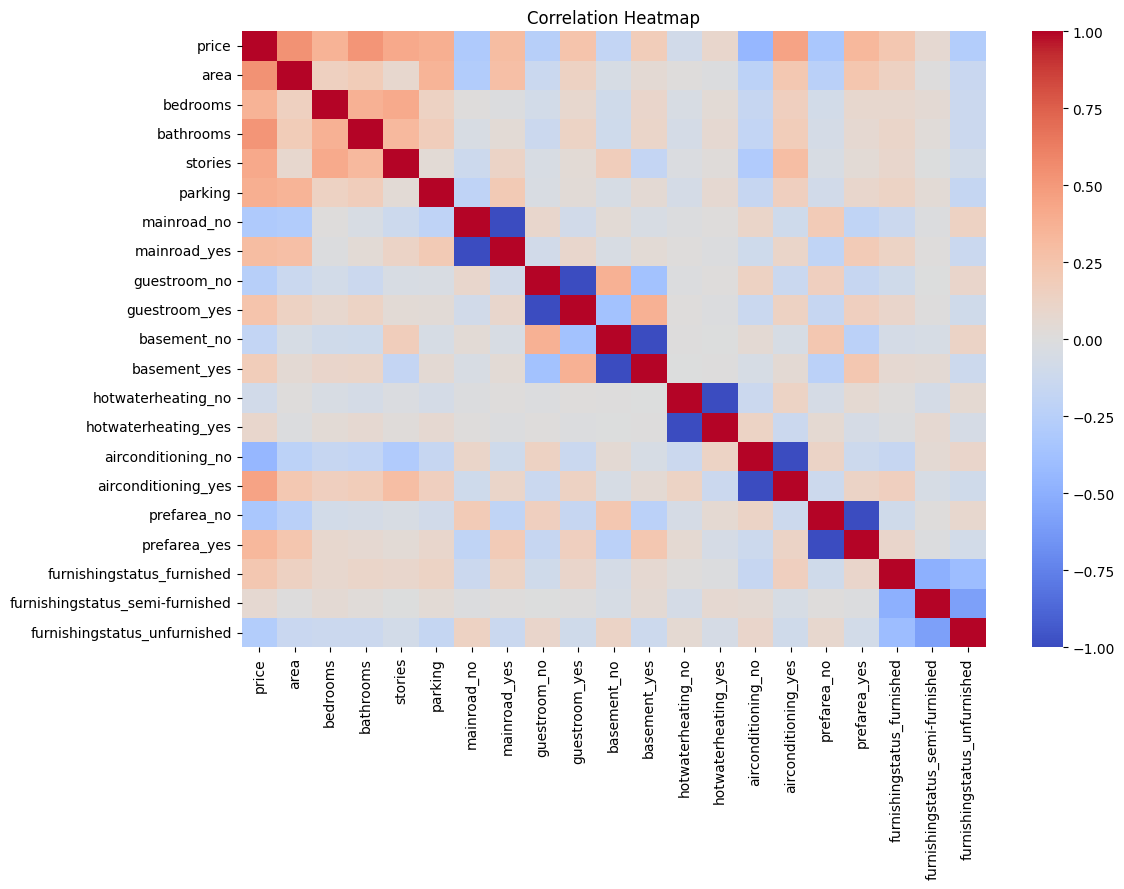

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_encode_obj.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

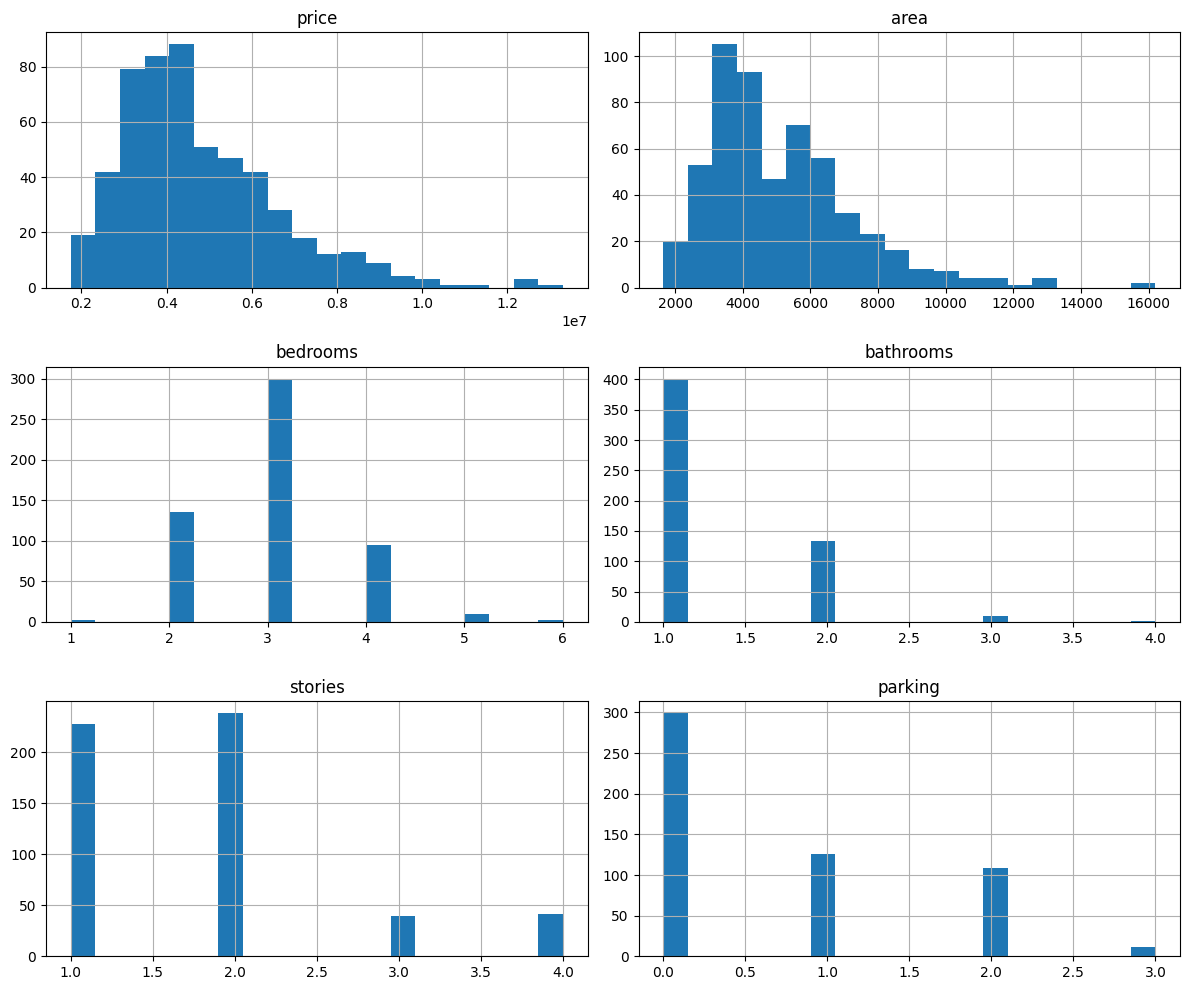

In [ ]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

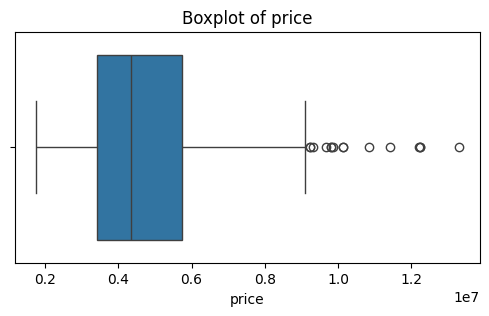

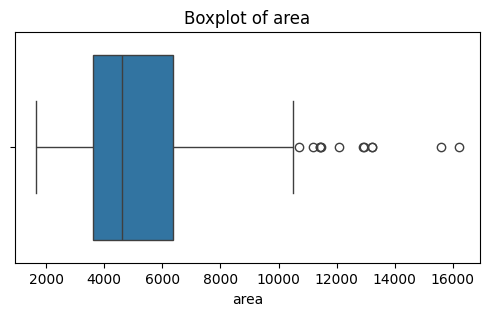

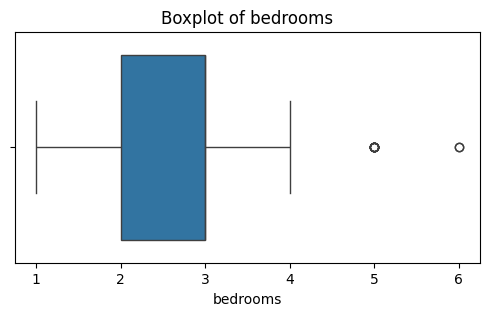

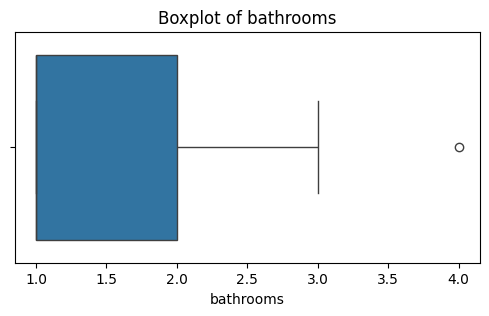

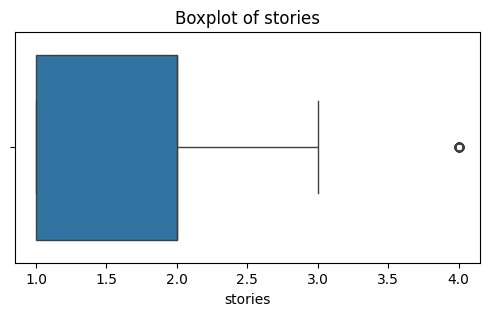

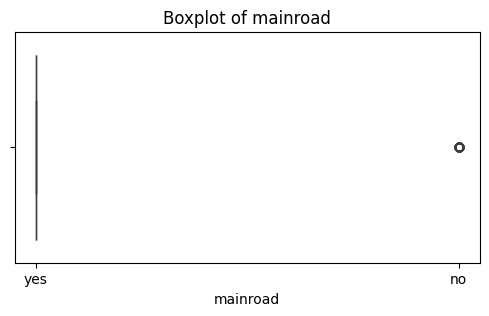

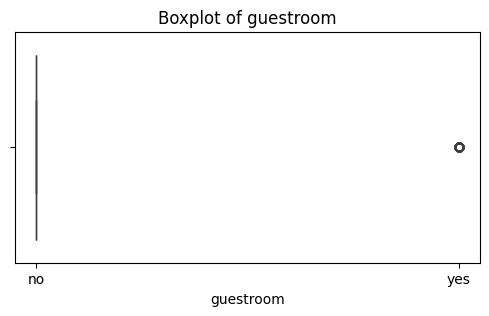

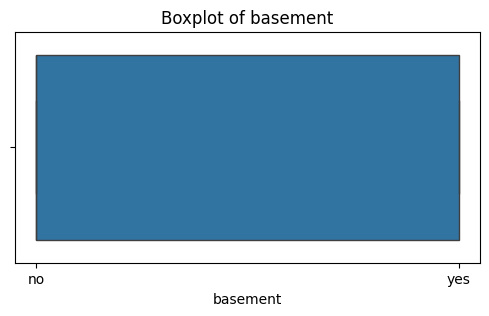

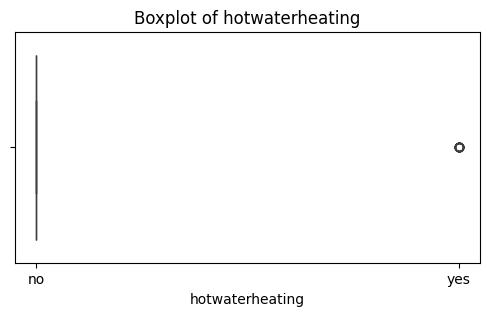

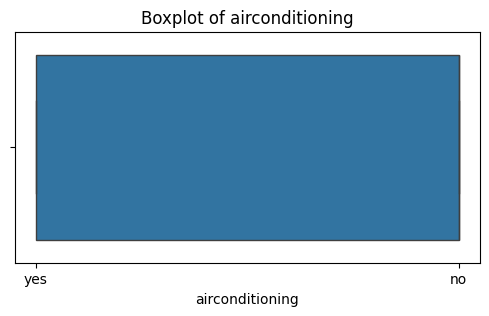

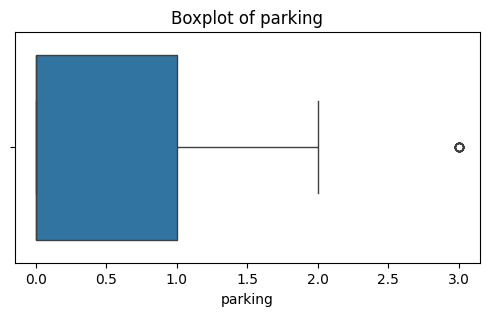

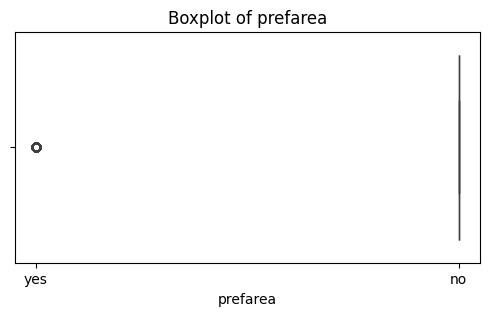

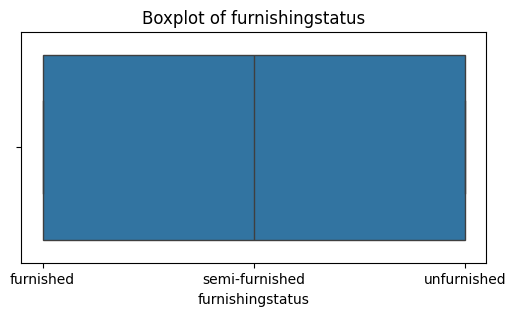

In [ ]:
for col in df:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# model_preprossing

In [ ]:
df_encode_obj.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_no', 'mainroad_yes', 'guestroom_no', 'guestroom_yes',
       'basement_no', 'basement_yes', 'hotwaterheating_no',
       'hotwaterheating_yes', 'airconditioning_no', 'airconditioning_yes',
       'prefarea_no', 'prefarea_yes', 'furnishingstatus_furnished',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

In [ ]:
corr = df_encode_obj.corr()

print(corr['price'].sort_values(ascending=False))

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
furnishingstatus_furnished         0.229350
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
hotwaterheating_no                -0.093073
basement_no                       -0.187057
guestroom_no                      -0.255517
furnishingstatus_unfurnished      -0.280587
mainroad_no                       -0.296898
prefarea_no                       -0.329777
airconditioning_no                -0.452954
Name: price, dtype: float64


In [ ]:
scaler = StandardScaler()
col_sc = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

selected_feature = ['prefarea_yes', 'airconditioning_yes']
selected_feature = [*selected_feature, *col_sc]

df_encode_obj[col_sc] = scaler.fit_transform(df_encode_obj[col_sc])


In [ ]:
df_encode_obj[selected_feature].head(5)

,prefarea_yes,airconditioning_yes,area,bedrooms,bathrooms,stories,parking
0,1,1,1.046726,1.403419,1.421812,1.378217,1.517692
1,0,1,1.757010,1.403419,5.405809,2.532024,2.679409
2,1,0,2.218232,0.047278,1.421812,0.224410,1.517692
3,1,1,1.083624,1.403419,1.421812,0.224410,2.679409
4,0,1,1.046726,1.403419,-0.570187,0.224410,1.517692


# model_training_spliting

In [ ]:
X = df_encode_obj[selected_feature]
y = df_encode_obj['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(436, 7)
(109, 7)
(436,)
(109,)


# linear regression

In [ ]:
model_reg = LinearRegression()

# model_reg = LinearRegression(
#     fit_intercept=True,
#     copy_X=True,
#     positive=False
# )

# param_grid_li_reg = {
#     'fit_intercept': [True, False],
#     'positive': [True, False]
# }

# grid_li_reg = GridSearchCV(
#     LinearRegression(),
#     param_grid_li_reg,
#     cv=5,
#     scoring='r2'
# )

# grid_li_reg.fit(X_train, y_train)

model_reg.fit(X_train, y_train)

LinearRegression()

In [ ]:
# with open("model.pkl", "wb") as file:
#     pickle.dump(model_reg, file)

pickle.dump(model_reg, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [ ]:
print(model_reg.feature_names_in_)

['prefarea_yes' 'airconditioning_yes' 'area' 'bedrooms' 'bathrooms'
 'stories' 'parking']


In [ ]:
print("Best Parameters:", grid_li_reg.best_params_)
print("Best Score:", grid_li_reg.best_score_)

NameError: name 'grid_li_reg' is not defined

cross validation

In [ ]:
score_cross_val_linear = cross_val_score(
    model_reg,
    X,
    y,
    cv=2,
    scoring='r2'
)

In [ ]:
print("Cross Validation Scores:")
print(score_cross_val_linear)

print("\nAverage R2 Score:")
print(score_cross_val_linear.mean())

check for overfitting and underfitting

In [ ]:
train_pred_over = model_reg.predict(X_train)
test_pred_over = model_reg.predict(X_test)

In [ ]:
train_r2 = r2_score(y_train, train_pred_over)
test_r2 = r2_score(y_test, test_pred_over)

print("Training R2 Score:", train_r2)
print("Testing R2 Score:", test_r2)

In [ ]:
model_pred_reg = model_reg.predict(X_test)

In [ ]:
# MAE
mae_reg = mean_absolute_error(y_test, model_pred_reg)

# MSE
mse_reg = mean_squared_error(y_test, model_pred_reg)

# RMSE
rmse_reg = np.sqrt(mse_reg)

# R2 Score
r2_reg = r2_score(y_test, model_pred_reg)

# Print Results
print("MAE :", mae_reg)
print("MSE :", mse_reg)
print("RMSE :", rmse_reg)
print("R2 Score :", r2_reg)

In [ ]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': model_pred_reg
})

print(comparison.head(10))

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, model_pred_reg)

plt.plot(
    [y_test.min(), model_pred_reg.max()],
    [y_test.min(), model_pred_reg.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

check under fitting or overfitting

In [ ]:
print("Train Score :", model_reg.score(X_train, y_train))
print("Test Score :", model_reg.score(X_test, y_test))

# Ridge

In [ ]:
model_redge = Ridge()

param_ridge = {
        'alpha': [0.01, 0.1, 1, 10, 100],
    'fit_intercept': [True, False],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}

grid_ridge = GridSearchCV(
    estimator=model_redge,
    param_grid=param_ridge,
    cv=5,
    scoring='r2'
)


grid_ridge.fit(X_train, y_train)

# model_redge.fit(X_train, y_train)

In [ ]:
print("Best Parameters:", grid_ridge.best_params_)
print("Best Score:", grid_ridge.best_score_)

cross validation

In [ ]:
cross_val_score_ridge = cross_val_score(
    model_redge,
    X,
    y,
    cv=2,
    scoring='r2'
)

In [ ]:
print("Cross Validation Scores:")
print(cross_val_score_ridge)

print("\nAverage R2 Score:")
print(cross_val_score_ridge.mean())

In [ ]:
model_pred_redge = model_redge.predict(X_test)

In [ ]:
# MAE
mae_redge = mean_absolute_error(y_test, model_pred_redge)

# MSE
mse_redge = mean_squared_error(y_test, model_pred_redge)

# RMSE
rmse_redge = np.sqrt(mse_redge)

# R2 Score
r2_redge = r2_score(y_test, model_pred_redge)

# Print Results
print("MAE :", mae_redge)
print("MSE :", mse_redge)
print("RMSE :", rmse_redge)
print("R2 Score :", r2_redge)

# Lasso

In [ ]:
model_la = Lasso()

param_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'fit_intercept': [True, False],
    'max_iter': [1000, 5000, 10000]
}

# Step 9: GridSearchCV
grid_search_lasso = GridSearchCV(
    estimator=model_la,
    param_grid=param_lasso,
    cv=5,
    scoring='r2'
)

grid_search_lasso.fit(X_train, y_train)

# model_la.fit(X_train, y_train)

In [ ]:
print("Best Parameters:", grid_search_lasso.best_params_)
print("Best Score:", grid_search_lasso.best_score_)

In [ ]:
model_pred_la = model_la.predict(X_test)

In [ ]:
# MAE
mae_la = mean_absolute_error(y_test, model_pred_la)

# MSE
mse_la = mean_squared_error(y_test, model_pred_la)

# RMSE
rmse_la = np.sqrt(mse_la)

# R2 Score
r2_la = r2_score(y_test, model_pred_la)

# Print Results
print("MAE :", mae_la)
print("MSE :", mse_la)
print("RMSE :", rmse_la)
print("R2 Score :", r2_la)

# KNN alorithm

In [ ]:
# knn_reg = KNeighborsRegressor(n_neighbors=9)

from sklearn.model_selection import RandomizedSearchCV

knn_reg = KNeighborsRegressor()

param_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

param_knn_random = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Step 9: GridSearchCV
grid_search_knn = GridSearchCV(
    estimator=knn_reg,
    param_grid=param_knn,
    cv=5,
    scoring='r2'
)
 # random search cv
random_search_knn = RandomizedSearchCV(
    estimator=knn_reg,
    param_distributions=param_knn_random,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# grid_search_knn.fit(X_train, y_train)
random_search_knn.fit(X_train, y_train)

# knn_reg.fit(X_train, y_train)


In [ ]:
print("Best Parameters:", random_search_knn.best_params_)
print("Best Score:", random_search_knn.best_score_)

In [ ]:
knn_reg_pred = knn_reg.predict(X_test)

In [ ]:
# MAE
mae_knn_reg = mean_absolute_error(y_test, knn_reg_pred)

# MSE
mse_knn_reg = mean_squared_error(y_test, knn_reg_pred)

# RMSE
rmse_knn_reg = np.sqrt(mae_knn_reg)

# R2 Score
r2_knn_reg = r2_score(y_test, knn_reg_pred)

# Print Results
print("MAE :", mae_knn_reg)
print("MSE :", mse_knn_reg)
print("RMSE :", rmse_knn_reg)
print("R2 Score :", r2_knn_reg)

# decision tree regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor


In [ ]:
# model_dt_reg = DecisionTreeRegressor()
model_dt_reg = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)


model_dt_reg.fit(X_train, y_train)

In [ ]:
model_pred_dt_reg = model_dt_reg.predict(X_test)

In [ ]:
# MAE
mae_dt_reg = mean_absolute_error(y_test, model_pred_dt_reg)

# MSE
mse_dt_reg = mean_squared_error(y_test, model_pred_dt_reg)

# RMSE
rmse_dt_reg = np.sqrt(mae_dt_reg)

# R2 Score
r2_dt_reg = r2_score(y_test, model_pred_dt_reg)

# Print Results
print("MAE :", mae_dt_reg)
print("MSE :", mse_dt_reg)
print("RMSE :", rmse_dt_reg)
print("R2 Score :", r2_dt_reg)

# comparison model

first try

In [ ]:
# results = pd.DataFrame({
#     'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Knn'],

#     'R2 Score': [
#         r2_reg,
#         r2_redge,
#         r2_la,
#         r2_knn_reg
#     ],

#     'RMSE': [
#         rmse_reg,
#         rmse_redge,
#         rmse_la,
#         rmse_knn_reg
#     ]
# })

# print(results)

second try

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Knn'],

    'R2 Score': [
        r2_reg,
        r2_redge,
        r2_la,
        r2_knn_reg
    ],

    'RMSE': [
        rmse_reg,
        rmse_redge,
        rmse_la,
        rmse_knn_reg
    ]
})

print(results)

# deployment

### Deployment: Saving and Loading the Linear Regression Model

In [ ]:
import joblib
from sklearn.pipeline import Pipeline

model_dep_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

In [ ]:
model_dep_reg.fit(X_train, y_train)

In [ ]:
train_pred_dep_reg = model_dep_reg.predict(X_train)
test_pred_dep_reg = model_dep_reg.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred_dep_reg))
print("Test R2:", r2_score(y_test, test_pred_dep_reg))

In [ ]:
joblib.dump(model_dep_reg, "model.pkl")

print("Model saved successfully!")